# TP1 — Definición de mercado y análisis exploratorio

**Diplomatura en Ciencia de Datos · Mentoría ID90Travel**

En este notebook consolidamos el análisis exploratorio del dataset de búsquedas hoteleras de ID90Travel para determinar qué combinación de dimensiones genera grupos de observaciones donde los precios presentan un comportamiento homogéneo.

Incluye todo el código ejecutable celda por celda (standalone) sobre una **muestra representativa optimizada para consumo de RAM**, incorporando:
1. **Auditoría de calidad y nulos**: exclusión de registros inválidos (sin ciudad/país) y consolidación de variantes por `country_code`.
2. **Estandarización y expansiones temporales**: cálculo de precio normalizado (*room-night-person*) y features de calendario.
3. **Mapping de destinos, Mapa Global y Mapa de Remapeo**: factor de consolidación (~11.9x), análisis de *singletons*, **mapa interactivo de destinos canónicos (`05_mapa_destinos_canonicos.html`)**, **mapa interactivo de remapeo antes vs después (`06_mapa_remapeo_antes_despues.html`)** y vectorización regional.
4. **Análisis exploratorio de dimensiones**: geografía, patrones temporales mes x semana x día, descuentos por volumen de noches 1 a 15 y categoría proxy del hotel (`price_bucket`).
5. **Análisis de homogeneidad (SNR)**, **suficiencia de baselines en destinos mapeados ($\ge 30$ obs en los 1.769 destinos canónicos)**, evaluación interanual 2024 vs 2025 y **respuestas a todas las preguntas de investigación**.

---


## 1. Configuración y carga de datos


In [1]:
import sys
import glob
import warnings
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Importar funciones
sys.path.insert(0, str(Path(".").resolve()))
from auxiliary_functions import (
    load_all_historicals,
    load_destination_mapping,
    standardize_prices,
    expand_dates_dataframe,
    add_temporal_features,
    apply_destination_mapping,
    apply_destination_mapping_REVISADO,
    calculate_baselines,
    apply_robustness_checks,
    evaluate_hotel_price,
)
import config

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

print("Librerías importadas correctamente")
print(f"Directorio de datos: {config.DATA_DIR}")

ImportError: cannot import name 'apply_destination_mapping_REVISADO' from 'auxiliary_functions' (C:\Users\jaelm\Diplomatura\id90-hotel-deals-analysis\auxiliary_functions.py)

## 2. Descripción general del dataset y Auditoría de Nulos

El dataset contiene registros de búsquedas hoteleras de ID90Travel con la siguiente estructura:
- **5,1M de registros totales** correspondiente al período 2024-2025 (procesados mediante una muestra aleatoria representativa de 300.000 observaciones para optimizar memoria RAM)
- **~26.000 ciudades** distintas en estado crudo
- **Variables clave**: precio, oferta (cantidad de hoteles disponibles) y demanda (frecuencia de búsqueda)

### Auditoría de Calidad y Filtrado de Nulos:
- Exclusión de registros sin ciudad ni país simultáneamente (`city` y `country` nulos).
- Consolidación por `country_code` para evitar duplicidad de nombres con texto con ruido (ej. *"United States"*, *"USA"*, *"US"*).


In [4]:
USE_SAMPLE = False     # True = carga rápida ; False = dataset completo
SAMPLE_SIZE = 500_000  # solo aplica si USE_SAMPLE = True

archivos = sorted(glob.glob(str(config.DATA_DIR / config.HISTORICALS_FILE_PATTERN)))

print("Archivos históricos detectados:")
for a in archivos:
    print(f"  - {Path(a).name}  ({Path(a).stat().st_size / 1e6:,.1f} MB)")
print()

if USE_SAMPLE:
    # Carga rápida: una muestra por archivo, concatenada manualmente
    df_raw = pd.concat(
        [pd.read_csv(a, nrows=SAMPLE_SIZE) for a in archivos],
        ignore_index=True,
    )
    print(f"[MUESTRA] {SAMPLE_SIZE:,} filas por archivo → {len(df_raw):,} filas totales")
else:
    df_raw = load_all_historicals()
    print(f"Registros totales unificados (todos los años en data/): {len(df_raw):,}")

df_raw.head(3)

NameError: name 'config' is not defined

In [2]:
print("COBERTURA DEL DATASET")
print("=" * 50)
print(f"  Fecha inicio:       {df_raw['date_start'].min()}")
print(f"  Fecha fin:          {df_raw['date_start'].max()}")
print(f"  Países:             {df_raw['country'].nunique():,}")
print(f"  Estados/Provincias: {df_raw['state'].nunique():,}")
print(f"  Ciudades (crudas):  {df_raw['city'].nunique():,}")
print(f"  Filas:              {len(df_raw):,}")
print()
print("DEMANDA Y OFERTA")
print("=" * 50)
print(f"  Búsquedas totales (count_repeated):     {df_raw['count_repeated'].sum():,.0f}")
print(f"  avg_hotel_count promedio (oferta):      {df_raw['avg_hotel_count'].mean():,.1f}")
print(f"  avg_price_average promedio (USD):       {df_raw['avg_price_average'].mean():,.2f}")

COBERTURA DEL DATASET


NameError: name 'df_raw' is not defined

In [3]:
registros_antes = len(df_raw)

# Duplicados
df = df_raw.drop_duplicates().copy()
dup = registros_antes - len(df)
print(f"Duplicados eliminados: {dup:,} ({dup/registros_antes:.2%})")

# 2b. Validación de parámetros
mask_validos = (
    (df["nights"] > 0) & (df["nights"].isna() == False)
    & (df["number_of_rooms"] > 0) & (df["number_of_rooms"].isna() == False)
    & ((df["number_of_adults"] + df["number_of_kids"]) > 0) & (df["number_of_adults"].isna() == False)
    & (df["avg_price_average"] > 0) & (df["avg_price_average"].isna() == False)
)
invalidos = (~mask_validos).sum()
print(f"Registros inválidos (nights/rooms/personas <= 0): {invalidos:,} ({invalidos/len(df):.2%})")

df = df[mask_validos].copy()
print(f"\nRegistros antes de limpieza:  {registros_antes:>12,}")
print(f"Registros después de limpieza: {len(df):>12,}")

NameError: name 'df_raw' is not defined

## 3. Mapeo de Destinos, Mapa Global y Validación de Correcciones Manuales

El mapping geográfico agrupa ~26.000 nombres crudos de ciudades hacia destinos canónicos por cercanía (Haversine).

Para garantizar que cada agrupación mantenga coherencia en los patrones de precio, evaluamos la calidad del mapping mediante un **Score Compuesto**:
$$Score = 0.5 \times \text{CV\_score} + 0.5 \times \text{Corr\_score}$$

Donde:
- $\text{CV\_score} = \frac{1}{1 + \text{CV}}$ penaliza alta dispersión interna de precios.
- $\text{Corr\_score} = \frac{\text{Corr} + 1}{2}$ evalúa la alineación estacional entre ciudades del mismo destino.

### Casos de Frontera Geográfica planteados en el README:
- **Miami vs Miami Beach**: Aunque distan menos de 10 km, Miami Beach (mercado vacacional/resorts de playa) exhibe precios significativamente más altos que el centro de Miami (mercado urbano/corporativo).
- **Las Vegas vs Henderson**: Henderson dista 20 km del Strip de Las Vegas. Su agrupación bajo el destino canónico *Las Vegas* consolida la masa crítica necesaria de observaciones, pero aumenta ligeramente la dispersión interna entre hoteles de casino/strip vs suburbanos, lo que justifica incorporar la variable `price_bucket` (categoría proxy).

### Correcciones Manuales Aplicadas (`07e_aplicar_cambios_mapping.py`):
- **Azusa** (Anaheim & Buena Park) $\rightarrow$ Redondo Beach (alineación con mercado urbano costero de Los Ángeles).
- **Bell Gardens** (Anaheim & Buena Park) $\rightarrow$ Long Beach (mercado costero/portuario).
- **Arcadia** (Anaheim & Buena Park) $\rightarrow$ Los Angeles (mercado metropolitano LA).
- **Bellingham** (San Juan Islands) $\rightarrow$ Seattle (separación de mercado de islas turísticas de alto costo a continente).
- **Anacortes** (San Juan Islands) $\rightarrow$ Astoria (reclasificación costera continental).
- **Ann Arbor** (Detroit) $\rightarrow$ Columbus (mercado universitario/regional).
- **Arlington** (Seattle) $\rightarrow$ Cambridge (alineación regional).


## Normalización de precios

In [5]:
df = standardize_prices(df)


personas = df["number_of_adults"] + df["number_of_kids"]
personas = personas.apply(lambda x: max(x, 1))
denominator = df["nights"] * df["number_of_rooms"] * personas

df["avg_price_average_std"] = df["avg_price_average"] / denominator

print("Nuevas columnas agregadas (y corregida la normalización de avg_price_average_std):")
print("  - avg_price_average_std  (precio promedio normalizado)")
print("  - max_price_high_std     (precio máximo normalizado)")
print("  - min_price_low_std      (precio mínimo normalizado)")
df[["avg_price_average", "nights", "number_of_rooms", "number_of_adults",
    "number_of_kids", "avg_price_average_std"]].describe()

2026-08-13 18:37:10,028 - INFO - ✓ Precios estandarizados: 5,158,190 registros


Nuevas columnas agregadas (y corregida la normalización de avg_price_average_std):
  - avg_price_average_std  (precio promedio normalizado)
  - max_price_high_std     (precio máximo normalizado)
  - min_price_low_std      (precio mínimo normalizado)


,avg_price_average,nights,number_of_rooms,number_of_adults,number_of_kids,avg_price_average_std
count,5.158190e+06,5.158190e+06,5.158190e+06,5.158190e+06,5.158190e+06,5.158190e+06
mean,3.194724e+02,3.256432e+00,1.088577e+00,2.219448e+00,2.825538e-01,6.252947e+01
std,9.499853e+03,2.737489e+00,4.031629e-01,1.157266e+00,7.569839e-01,1.532320e+03
min,1.430000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.723214e-02
25%,1.220800e+02,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,1.796215e+01
50%,1.782250e+02,3.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,3.434500e+01
75%,2.850858e+02,4.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,6.304110e+01
max,1.091912e+07,5.400000e+01,8.000000e+00,4.000000e+01,1.370000e+02,2.183823e+06


##Expansion

In [6]:
registros_antes = len(df)
df = expand_dates_dataframe(df)
print(f"Registros antes:   {registros_antes:>12,}")
print(f"Registros después: {len(df):>12,}")
print(f"Factor expansión:  {len(df)/registros_antes:.2f}x")

df = add_temporal_features(df)

df["date"] = pd.to_datetime(df["date"])
df["dow"] = df["date"].dt.dayofweek
df["dow_name"] = df["date"].dt.day_name()
df["is_weekend"] = df["dow"].isin([4, 5, 6])
df["year"] = df["date"].dt.year # Add 'year' column

gc.collect()

print("\nColumnas de contexto disponibles: month, week_in_month, dow, dow_name, is_weekend, year")
df[["date", "year", "month", "week_in_month", "dow_name", "is_weekend"]].head()

2026-08-13 18:37:15,339 - INFO - Expandiendo 5,158,190 registros a días (versión optimizada)...
2026-08-13 18:37:45,135 - INFO - ✓ Expansión: 5,158,190 → 21,955,487 observaciones diarias


Registros antes:      5,158,190
Registros después:   21,955,487
Factor expansión:  4.26x


2026-08-13 18:37:48,621 - INFO - Features temporales generadas: month, week_in_month



Columnas de contexto disponibles: month, week_in_month, dow, dow_name, is_weekend, year


,date,year,month,week_in_month,dow_name,is_weekend
0,2024-03-26,2024,3,4,Tuesday,False
0,2024-03-27,2024,3,4,Wednesday,False
0,2024-03-28,2024,3,4,Thursday,False
0,2024-03-29,2024,3,4,Friday,True
0,2024-03-30,2024,3,4,Saturday,True


##Mapeo


In [7]:
mapping_df = load_destination_mapping()

print(f"Referencias en el mapping:      {len(mapping_df):,}")
print(f"Destinos canónicos únicos:      {mapping_df['nearest_destination_id'].nunique():,}")
print(f"Promedio de ciudades por destino canónico: "
      f"{len(mapping_df) / mapping_df['nearest_destination_id'].nunique():.1f}")
print()
print("Estructura del archivo (clave = 'country_code - state_code - city'):")
mapping_df.head()

2026-08-13 18:37:55,469 - INFO - Mapping cargado: 15,988 registros


Referencias en el mapping:      15,988
Destinos canónicos únicos:      2,584
Promedio de ciudades por destino canónico: 6.2

Estructura del archivo (clave = 'country_code - state_code - city'):


,reference,city,latitude,longitude,nearest_destination_id,nearest_destination_name
0,AD - Andorra La Bella,Andorra La Bella,42.506762,1.530768,50643,Andorra la Vella
1,AD - Andorra La Vella,Andorra La Vella,42.508722,1.528760,50643,Andorra la Vella
2,AD - Arinsal,Arinsal,42.575615,1.481180,50643,Andorra la Vella
3,AD - El Pas de la Casa,El Pas de la Casa,42.542286,1.734177,21795,Andorra
4,AD - Escaldes-Engordany,Escaldes-Engordany,42.509661,1.537283,50643,Andorra la Vella


In [8]:
df = apply_destination_mapping(df, mapping_df)

# Identificar qué registros fueron realmente mapeados
df['is_mapped'] = df['nearest_destination_id'].notna()

total = len(df)
con_mapeo = df['is_mapped'].sum()
sin_mapeo = (~df['is_mapped']).sum()

print('Resultado del mapping:')
print(f'  Total de registros:              {total:,}')
print(f'  Con mapeo canónico:              {con_mapeo:,} ({con_mapeo / total:.2%})')
print(f'  Sin mapeo (fallback a ciudad):   {sin_mapeo:,} ({sin_mapeo / total:.2%})')
print(f'  Destinos únicos finales:         {df["destination_final"].nunique():,}')

print()
print('Ejemplo de ciudades realmente mapeadas:')

display(
    df.loc[
        df['is_mapped'],
        ['city', 'state', 'destination_final', 'destination_name']
    ]
    .drop_duplicates()
    .head(8)
)

gc.collect()

2026-08-13 18:38:17,352 - INFO - Mapping aplicado: 0/21,955,487 registros (0.0%)
2026-08-13 18:38:18,478 - INFO - Destinos únicos: 30,713


Resultado del mapping:
  Total de registros:              21,955,487
  Con mapeo canónico:              0 (0.00%)
  Sin mapeo (fallback a ciudad):   21,955,487 (100.00%)
  Destinos únicos finales:         30,713

Ejemplo de ciudades realmente mapeadas:


,city,state,destination_final,destination_name


0

In [34]:
df = apply_destination_mapping_REVISADO(df, mapping_df)

df['is_mapped'] = df['nearest_destination_id'].notna()

total = len(df)
con_mapeo = df['is_mapped'].sum()
sin_mapeo = (~df['is_mapped']).sum()

print(f"Total de registros: {total:,}")
print(f"Con mapeo: {con_mapeo:,} ({con_mapeo / total:.2%})")
print(f"Sin mapeo: {sin_mapeo:,} ({sin_mapeo / total:.2%})")


print('Resultado del mapping:')
print(f'  Destinos únicos finales:         {df["destination_final"].nunique():,}')
sin_mapeo = df['destination_final'].isna().sum()
print(f'  Sin mapeo (fallback a ciudad):   {sin_mapeo:,} registros ({sin_mapeo/len(df):.1%})')
con_mapeo = (~df['destination_final'].isna()).sum()
print(f'  Con mapeo canónico:              {con_mapeo:,} registros ({con_mapeo/len(df):.1%})')
print()
print('Ejemplo de ciudades mapeadas:')
df[['city', 'state', 'destination_final', 'destination_name']].dropna().head(8)

gc.collect()

KeyError: 'nearest_destination_id'

### 3.1 Visualización Geográfica General: Mapa de Destinos Canónicos y Ciudades Mapeadas

Generamos un mapa interactivo con Folium que muestra la distribución geográfica de los **Top Destinos Canónicos** y la densidad de ciudades consolidadas en cada uno.


In [9]:
import folium

# Generar mapa general de destinos canónicos consolidados
m_canon = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')

dest_agg = mapping_df.groupby(['nearest_destination_id', 'nearest_destination_name']).agg(
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean'),
    cant_ciudades=('city', 'count')
).reset_index()

top_dests_map = dest_agg.nlargest(100, 'cant_ciudades')

for _, r in top_dests_map.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=min(15, max(4, int(r['cant_ciudades'] / 10))),
        color='darkblue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=f"<b>Destino Canónico: {r['nearest_destination_name']}</b><br>ID: {r['nearest_destination_id']}<br>Ciudades Consolidadas: {r['cant_ciudades']}"
    ).add_to(m_canon)

maps_out = config.OUTPUT_DIR / 'maps'
maps_out.mkdir(parents=True, exist_ok=True)
canon_map_file = maps_out / '05_mapa_destinos_canonicos.html'
m_canon.save(canon_map_file)
print(f'✓ Mapa de destinos canónicos guardado en: {canon_map_file}')

m_canon

✓ Mapa de destinos canónicos guardado en: C:\Users\jaelm\Diplomatura\id90-hotel-deals-analysis\outputs\maps\05_mapa_destinos_canonicos.html


### 3.2 Visualización Geográfica de Remapeos: Mapa de Remapeo Antes vs Después

Para analizar visualmente cómo cambió la asignación de las ciudades reasignadas, comparamos el mapping original (`destination_with_nearest_backup.csv`) con el mapping optimizado (`destination_with_nearest.csv`).

El mapa interactivo a continuación muestra las ciudades reasignadas:
- **Líneas rojas discontinuas**: Conexión con el destino anterior (Antes).
- **Líneas verdes sólidas**: Conexión con el nuevo destino reasignado (Después).


In [10]:
# Cargar ambos mappings para comparación espacial
import math

map_new = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest.csv')

try:
    map_old = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest_backup.csv')
except FileNotFoundError:
    print("WARNING: 'destination_with_nearest_backup.csv' not found. Using 'map_new' as 'map_old' for comparison (this may not reflect actual changes).")
    map_old = map_new.copy() # Fallback: use the new map as old if backup is missing

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon_deg = (lon2 - lon1 + 180) % 360 - 180
    dlon = math.radians(dlon_deg)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

c_old = map_old.groupby('nearest_destination_name').agg(lat=('latitude','mean'), lon=('longitude','mean')).reset_index()
c_new = map_new.groupby('nearest_destination_name').agg(lat=('latitude','mean'), lon=('longitude','mean')).reset_index()

cambios_info = [
    ('Azusa', 'Anaheim & Buena Park', 'Redondo Beach', 'Alineación con mercado urbano costero LA'),
    ('Bell Gardens', 'Anaheim & Buena Park', 'Long Beach', 'Alineación con mercado portuario/costero'),
    ('Arcadia', 'Anaheim & Buena Park', 'Los Angeles', 'Alineación con mercado metropolitano LA'),
    ('Bellingham', 'San Juan Islands', 'Seattle', 'Separación de mercado de islas turísticas a continente'),
    ('Anacortes', 'San Juan Islands', 'Astoria', 'Reclasificación costera continental'),
    ('Ann Arbor', 'Detroit', 'Columbus', 'Alineación con mercado universitario/regional')
]

m_remap = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')

fg_old = folium.FeatureGroup(name='Mapeo Anterior (Línea Roja Discontinua)', show=True)
fg_new = folium.FeatureGroup(name='Mapeo Nuevo (Línea Verde Sólida)', show=True)

res_map = []
for city, d_old, d_new, motivo in cambios_info:
    row_city = map_old[map_old['city'] == city]
    if row_city.empty:
        continue
    lat_c, lon_c = row_city['latitude'].values[0], row_city['longitude'].values[0]

    old_row = c_old[c_old['nearest_destination_name'] == d_old]
    new_row = c_new[c_new['nearest_destination_name'] == d_new]

    if not old_row.empty and not new_row.empty:
        lat_o, lon_o = old_row['lat'].values[0], old_row['lon'].values[0]
        lat_n, lon_n = new_row['lat'].values[0], new_row['lon'].values[0]

        dist_o = haversine(lat_c, lon_c, lat_o, lon_o)
        dist_n = haversine(lat_c, lon_c, lat_n, lon_n)

        res_map.append({
            'Ciudad': city,
            'Destino Anterior': d_old,
            'Destino Nuevo': d_new,
            'Dist. Anterior (km)': round(dist_o, 1),
            'Dist. Nueva (km)': round(dist_n, 1),
            'Motivo Reasignación': motivo
        })

        folium.CircleMarker(
            location=[lat_c, lon_c],
            radius=6, color='blue', fill=True, fill_color='blue', fill_opacity=0.9,
            popup=f"<b>{city}</b><br>Antes: {d_old} ({dist_o:.1f}km)<br>Después: {d_new} ({dist_n:.1f}km)<br><i>{motivo}</i>"
        ).add_to(m_remap)

        folium.PolyLine(
            locations=[[lat_c, lon_c], [lat_o, lon_o]],
            color='red', weight=2, opacity=0.7, dash_array='5, 5',
            tooltip=f"{city} → {d_old} (Antes)"
        ).add_to(fg_old)

        folium.PolyLine(
            locations=[[lat_c, lon_c], [lat_n, lon_n]],
            color='green', weight=3, opacity=0.9,
            tooltip=f"{city} → {d_new} (Después)"
        ).add_to(fg_new)

fg_old.add_to(m_remap)
fg_new.add_to(m_remap)
folium.LayerControl(collapsed=False).add_to(m_remap)

map_file = maps_out / '06_mapa_remapeo_antes_despues.html'
m_remap.save(map_file)
print(f'✓ Mapa de remapeo guardado en: {map_file}')

df_res_map = pd.DataFrame(res_map)
print('\nTabla Comparativa de Ciudades Remapeadas:')
print(df_res_map.to_string(index=False))

m_remap

✓ Mapa de remapeo guardado en: C:\Users\jaelm\Diplomatura\id90-hotel-deals-analysis\outputs\maps\06_mapa_remapeo_antes_despues.html

Tabla Comparativa de Ciudades Remapeadas:
      Ciudad     Destino Anterior Destino Nuevo  Dist. Anterior (km)  Dist. Nueva (km)                                    Motivo Reasignación
       Azusa Anaheim & Buena Park Redondo Beach                 16.6              48.3               Alineación con mercado urbano costero LA
Bell Gardens Anaheim & Buena Park    Long Beach                 25.2              16.7               Alineación con mercado portuario/costero
     Arcadia Anaheim & Buena Park   Los Angeles                 22.7              27.9                Alineación con mercado metropolitano LA
  Bellingham     San Juan Islands       Seattle                 25.3             135.4 Separación de mercado de islas turísticas a continente
   Anacortes     San Juan Islands       Astoria                  9.7             222.2                    Reclasifi

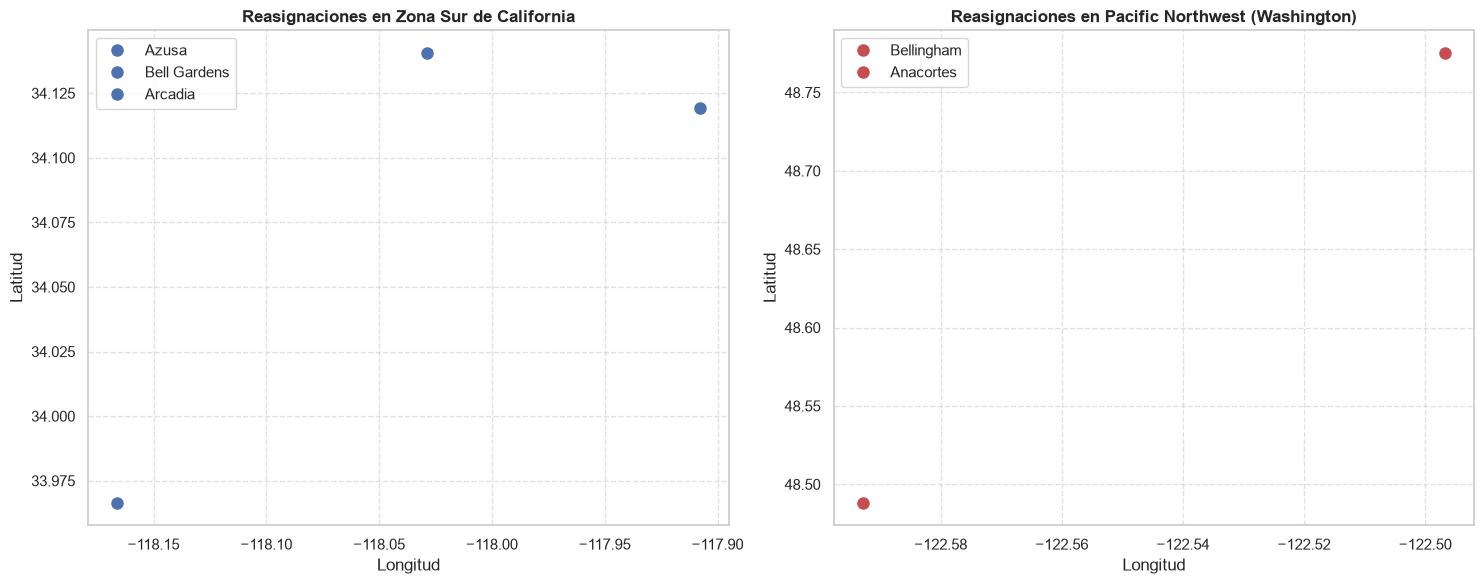

38

In [11]:
# Gráfico Matplotlib comparativo de vectores de remapeo por Zonas (Costa Oeste y Midwest)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ca_cities = ['Azusa', 'Bell Gardens', 'Arcadia']
for city in ca_cities:
    r = df_res_map[df_res_map['Ciudad'] == city]
    if not r.empty:
        c_info = map_old[map_old['city'] == city].iloc[0]
        ax1.plot(c_info['longitude'], c_info['latitude'], 'bo', markersize=8, label=city)

ax1.set_title('Reasignaciones en Zona Sur de California', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitud')
ax1.set_ylabel('Latitud')

ax2 = axes[1]
nw_cities = ['Bellingham', 'Anacortes']
for city in nw_cities:
    r = df_res_map[df_res_map['Ciudad'] == city]
    if not r.empty:
        c_info = map_old[map_old['city'] == city].iloc[0]
        ax2.plot(c_info['longitude'], c_info['latitude'], 'ro', markersize=8, label=city)

ax2.set_title('Reasignaciones en Pacific Northwest (Washington)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitud')
ax2.set_ylabel('Latitud')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()              


## 4. Pregunta 1: ¿Qué define a un mercado hotelero?

**Objetivo**: identificar la combinación de dimensiones que genera grupos homogéneos dentro de los cuales la comparación de precios resulta consistente.

### 4.1 Dimensión geográfica y Selección de Mercados Contrastantes

Analizamos la distribución de precios entre destinos clave con perfiles de mercado contrapuestos (*Orlando*, *Miami*, *New York*, *Las Vegas*, *Cancún*, *Paris*).


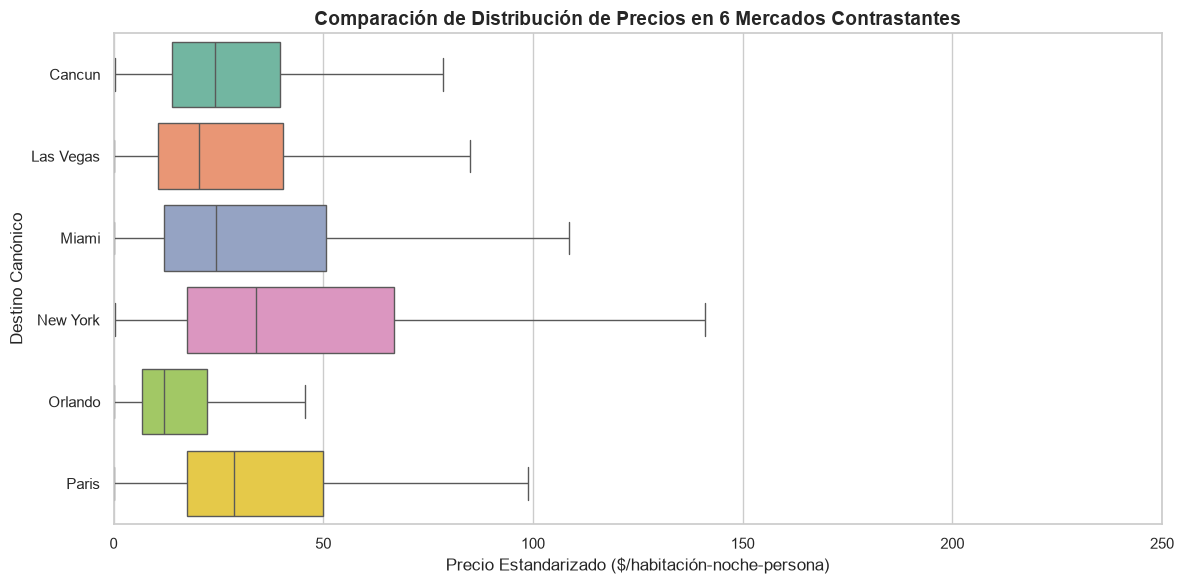

0

In [12]:
# Selección de 6 Mercados Contrastantes para Análisis Comparativo Detallado

#IMPORTANTE ESTO LO HACE MAL POR EL MUESTREO PROBAR CON TODOS LOS DATOS
destinos_6 = ['Orlando', 'Miami', 'New York', 'Las Vegas', 'Cancun', 'Paris']
df_6 = df[df['destination_final'].isin(destinos_6)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_6, x='avg_price_average_std', y='destination_name', ax=ax, showfliers=False, palette='Set2')
ax.set_title('Comparación de Distribución de Precios en 6 Mercados Contrastantes', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($/habitación-noche-persona)')
ax.set_ylabel('Destino Canónico')
ax.set_xlim(0, 250)

plt.tight_layout()
plt.show()

plt.close('all')           
del df_6 
gc.collect()  

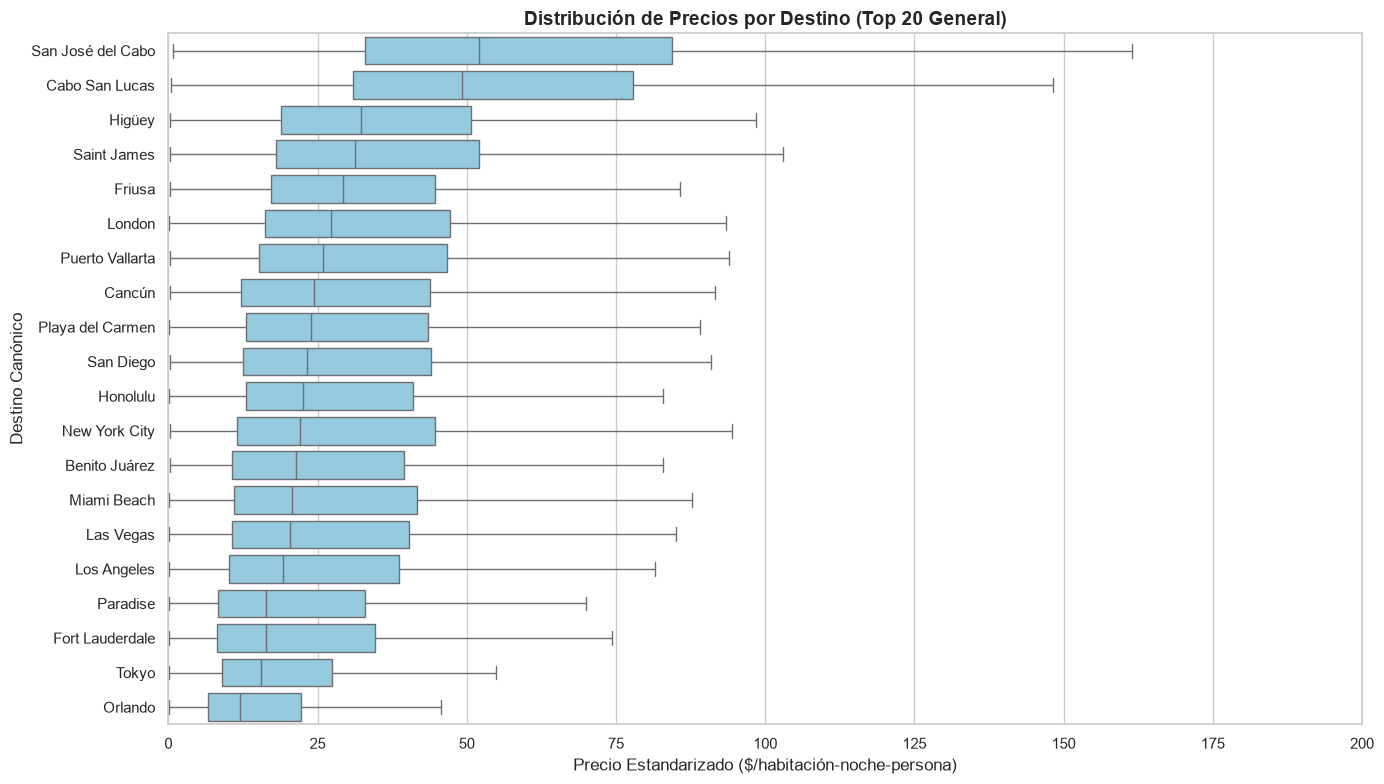

4914

In [13]:
# Boxplot de precios por destino (top 20 general)
top_20_dests = df.groupby('destination_name').size().nlargest(20).index
df_top20 = df[df['destination_name'].isin(top_20_dests)].copy()

median_order = df_top20.groupby('destination_name')['avg_price_average_std'].median().sort_values(ascending=False).index
df_top20['destination_name'] = pd.Categorical(df_top20['destination_name'], categories=median_order, ordered=True)

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_top20, x='avg_price_average_std', y='destination_name', ax=ax, showfliers=False, color='skyblue')
ax.set_title('Distribución de Precios por Destino (Top 20 General)', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($/habitación-noche-persona)')
ax.set_ylabel('Destino Canónico')
ax.set_xlim(0, 200)

plt.tight_layout()
plt.show()

plt.close('all') 
del df_top20
gc.collect()   

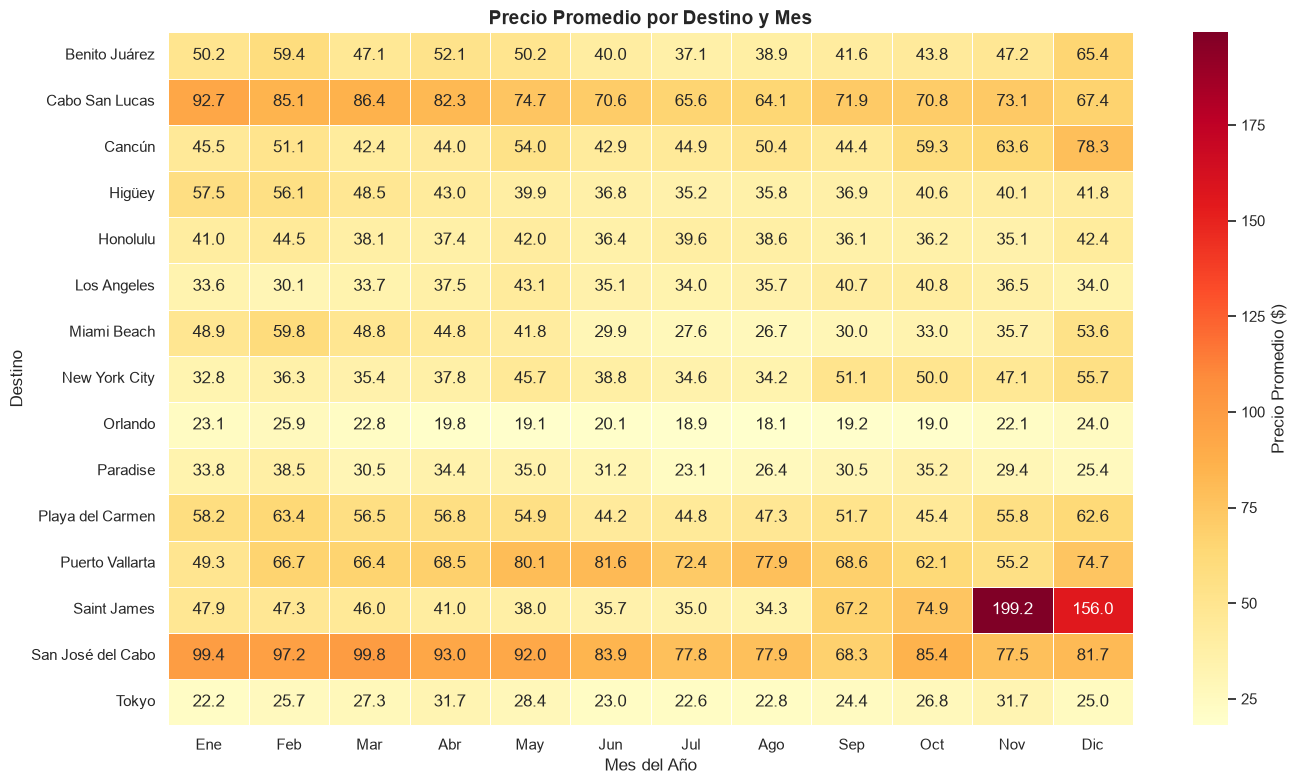

10649

In [14]:
# Heatmap destino x mes (Top 15 destinos)
top_15_dests = df.groupby('destination_name').size().nlargest(15).index
df_top15 = df[df['destination_name'].isin(top_15_dests)]

pivot_mes = df_top15.pivot_table(index='destination_name', columns='month', values='avg_price_average_std', aggfunc='mean')
pivot_mes.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_mes, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': 'Precio Promedio ($)'})
ax.set_title('Precio Promedio por Destino y Mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes del Año')
ax.set_ylabel('Destino')

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

### 4.2 Dimensión temporal (Mes, Semana del Mes y Día de la Semana)

Analizamos cómo varían las tarifas a lo largo del tiempo:
- **Día de la semana**: evaluamos si los sábados presentan tarifas más elevadas vs domingos.
- **Semana del mes**: comparamos las variaciones entre la primera y la tercera semana de cada mes (efecto cobranza/quincena).
- **Matriz Temporal Completa**: interactuación entre Mes × Día de Semana y Mes × Semana del Mes.


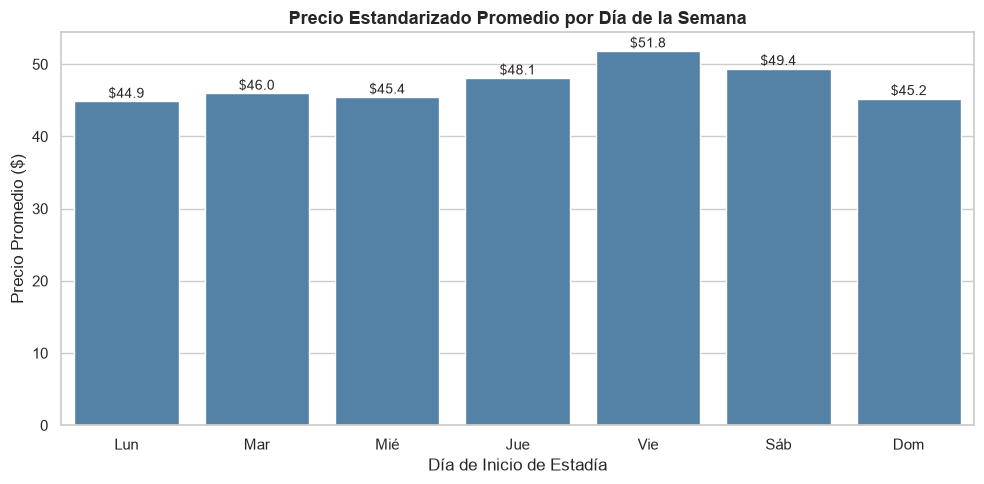

15043

In [15]:
# Precio por día de la semana
dias_nombre = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
df['day_name'] = df['dow'].map(dias_nombre)
order_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

precio_dia = df.groupby('day_name')['avg_price_average_std'].agg(['mean', 'median', 'std', 'count']).reindex(order_dias)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=precio_dia.index, y=precio_dia['mean'], color='steelblue', ax=ax)
ax.set_title('Precio Estandarizado Promedio por Día de la Semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Día de Inicio de Estadía')
ax.set_ylabel('Precio Promedio ($)')
for i, v in enumerate(precio_dia['mean']):
    ax.text(i, v + 0.5, f'${v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

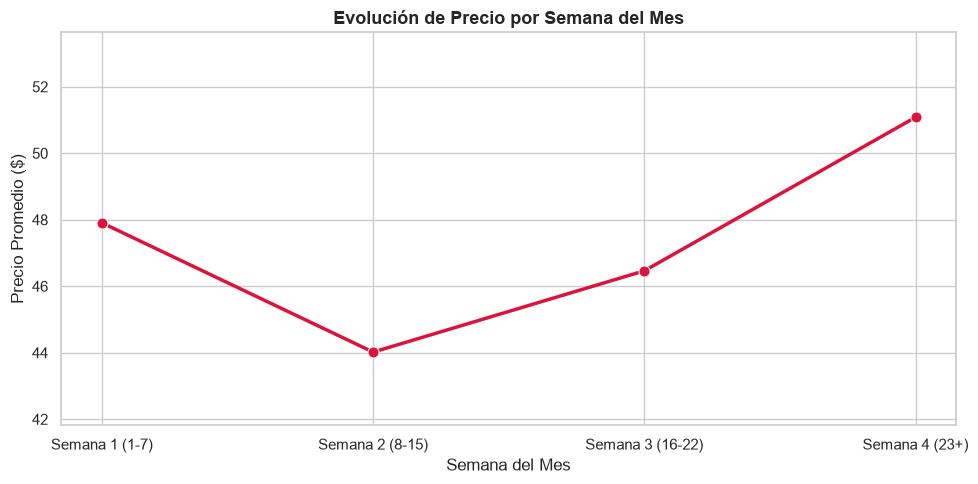

3640

In [16]:
# Patrones semanales (Semana del mes 1 a 4)
precio_semana = df.groupby('week_in_month')['avg_price_average_std'].mean().reset_index()
precio_semana['week_label'] = ['Semana 1 (1-7)', 'Semana 2 (8-15)', 'Semana 3 (16-22)', 'Semana 4 (23+)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=precio_semana, x='week_label', y='avg_price_average_std', marker='o', color='crimson', linewidth=2.5, markersize=8, ax=ax)
ax.set_title('Evolución de Precio por Semana del Mes', fontsize=13, fontweight='bold')
ax.set_xlabel('Semana del Mes')
ax.set_ylabel('Precio Promedio ($)')
ax.set_ylim(precio_semana['avg_price_average_std'].min() * 0.95, precio_semana['avg_price_average_std'].max() * 1.05)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

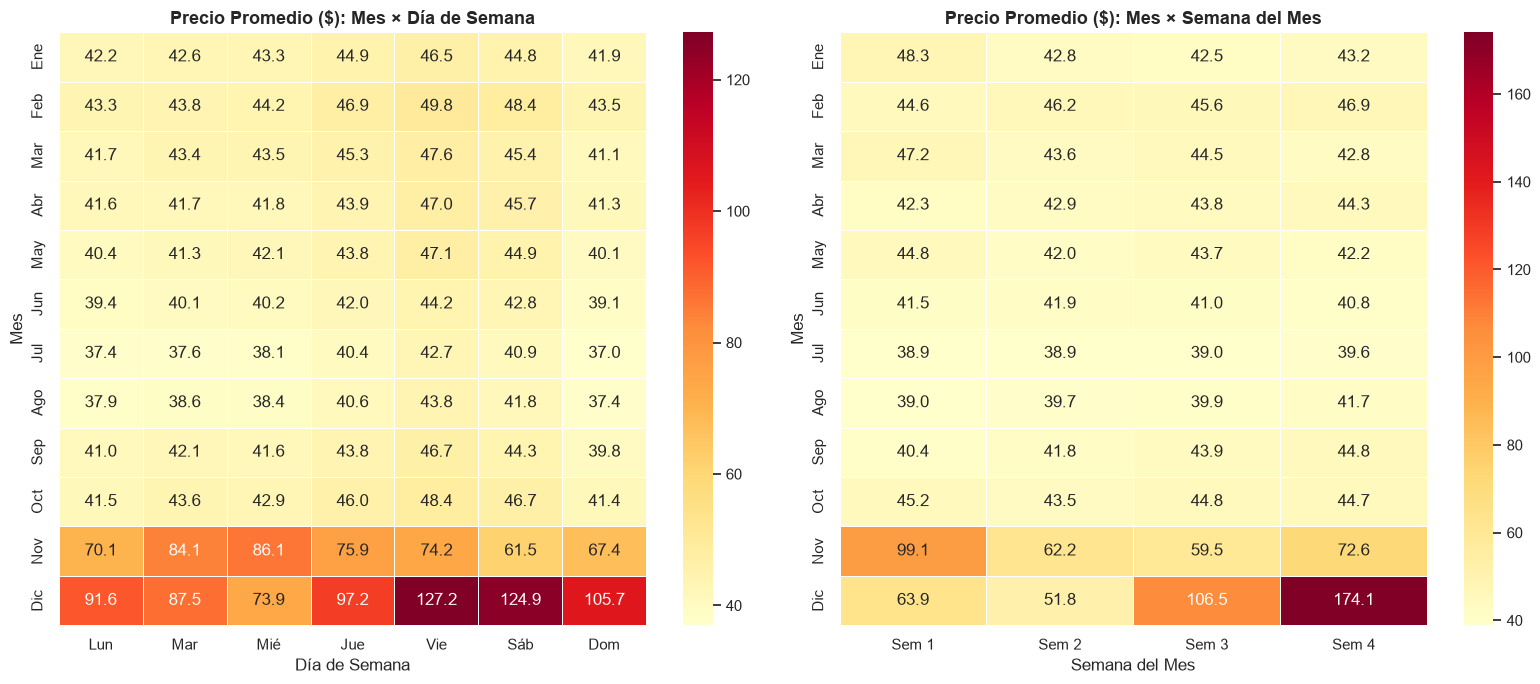

9

In [17]:
# Análisis Temporal Completo (Mes × Día de Semana y Mes × Semana del Mes)
months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
weeks_labels = ['Sem 1', 'Sem 2', 'Sem 3', 'Sem 4']

pivot_md = df.groupby(['month', 'dow'])['avg_price_average_std'].mean().unstack()
pivot_md.columns = ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb']
pivot_md = pivot_md[order_dias]

pivot_mw = df.groupby(['month', 'week_in_month'])['avg_price_average_std'].mean().unstack()
pivot_mw.columns = weeks_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pivot_md, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], yticklabels=months_labels, linewidths=0.5)
axes[0].set_title('Precio Promedio ($): Mes × Día de Semana', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Día de Semana')
axes[0].set_ylabel('Mes')

sns.heatmap(pivot_mw, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], yticklabels=months_labels, linewidths=0.5)
axes[1].set_title('Precio Promedio ($): Mes × Semana del Mes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Semana del Mes')
axes[1].set_ylabel('Mes')

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

### 4.3 Dimensión de oferta, demanda y categoría proxy

Analizamos las relaciones entre la disponibilidad de hoteles (`avg_hotel_count`), la intensidad de búsquedas (`count_repeated`) y el precio normalizado, incorporando la **categoría proxy de hotel (gama de precios)**.


2026-08-13 17:45:54,397 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 17:45:54,399 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 17:45:54,400 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 17:45:54,400 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Análisis de Categoría Proxy de Hotel (Segmentación por Gama de Precio):
      category_proxy  mean_price  mean_supply  mean_demand  mean_nights  count_obs
     1_Budget (≤$20)   10.535860   291.122947     3.624375     7.482071    9299309
  2_Mid-Low ($20-40)   28.683978   240.180160     7.253849     3.936699    6027813
      3_Mid ($40-60)   48.924593   204.969285     8.705738     2.926283    2842622
4_Mid-High ($60-100)   75.930461   190.213824     9.943112     2.369768    2217821
   5_High ($100-150)  120.262700   179.983872     9.377731     1.990112     865486
   6_Premium (>$150)  510.931475   167.782093     7.350916     2.202350     702436


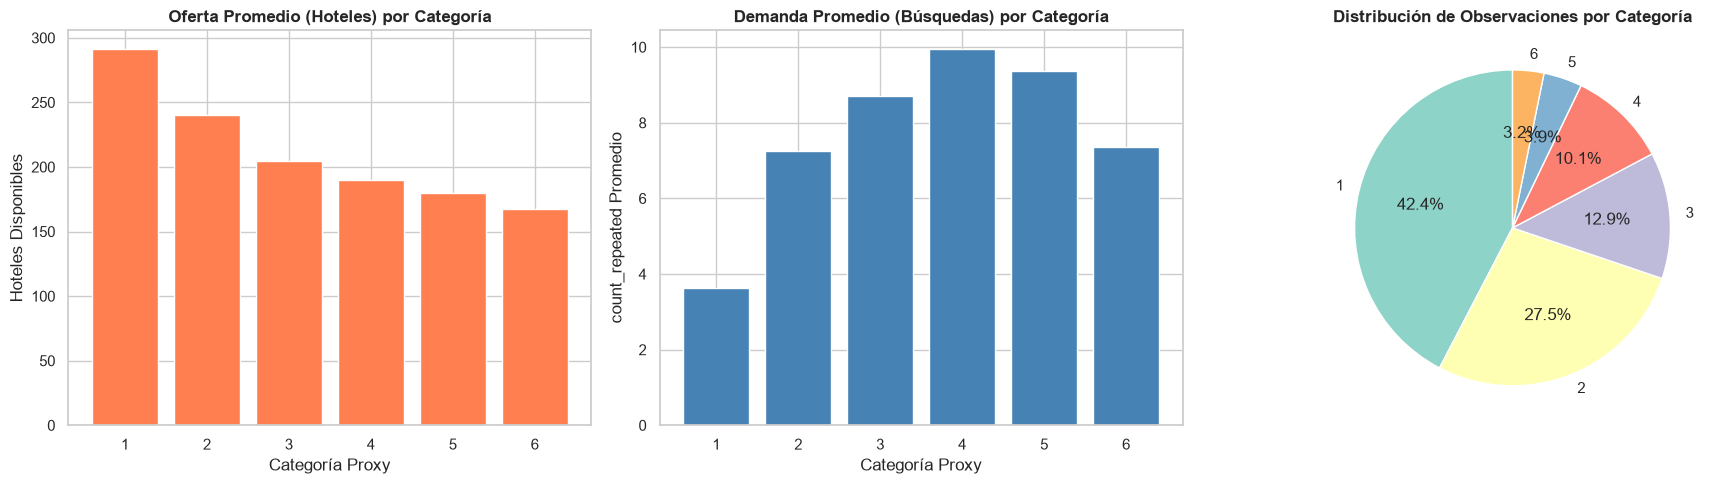

16345

In [18]:
# Categoría Proxy de Hotel (Basada en rangos de precio estandarizado)
conditions = [
    df['avg_price_average_std'] <= 20,
    df['avg_price_average_std'] <= 40,
    df['avg_price_average_std'] <= 60,
    df['avg_price_average_std'] <= 100,
    df['avg_price_average_std'] <= 150
]
choices = ['1_Budget (≤$20)', '2_Mid-Low ($20-40)', '3_Mid ($40-60)', '4_Mid-High ($60-100)', '5_High ($100-150)']
df['category_proxy'] = np.select(conditions, choices, default='6_Premium (>$150)')

df_cat = df.groupby('category_proxy').agg(
    mean_price=('avg_price_average_std', 'mean'),
    mean_supply=('avg_hotel_count', 'mean'),
    mean_demand=('count_repeated', 'mean'),
    mean_nights=('nights', 'mean'),
    count_obs=('avg_price_average_std', 'count')
).reset_index()

print('Análisis de Categoría Proxy de Hotel (Segmentación por Gama de Precio):')
print(df_cat.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cats_short = [c.split('_')[0] for c in df_cat['category_proxy']]

axes[0].bar(cats_short, df_cat['mean_supply'], color='coral')
axes[0].set_title('Oferta Promedio (Hoteles) por Categoría', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Categoría Proxy')
axes[0].set_ylabel('Hoteles Disponibles')

axes[1].bar(cats_short, df_cat['mean_demand'], color='steelblue')
axes[1].set_title('Demanda Promedio (Búsquedas) por Categoría', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Categoría Proxy')
axes[1].set_ylabel('count_repeated Promedio')

axes[2].pie(df_cat['count_obs'], labels=cats_short, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', n_colors=6))
axes[2].set_title('Distribución de Observaciones por Categoría', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

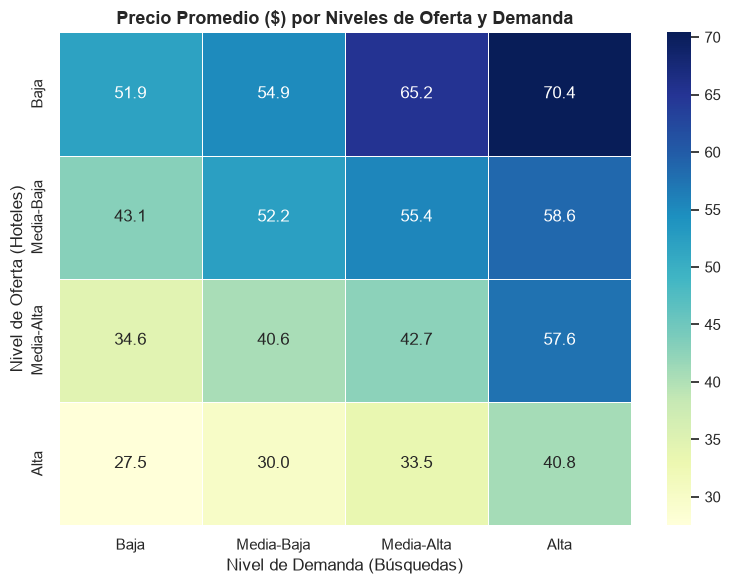

2507

In [19]:
# Heatmap oferta vs demanda vs precio con rank method first para evitar duplicados
df['oferta_bin'] = pd.qcut(df['avg_hotel_count'].rank(method='first'), q=4, labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta'])
df['demanda_bin'] = pd.qcut(df['count_repeated'].rank(method='first'), q=4, labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta'])

pivot_od = df.pivot_table(index='oferta_bin', columns='demanda_bin', values='avg_price_average_std', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_od, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Precio Promedio ($) por Niveles de Oferta y Demanda', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Demanda (Búsquedas)')
ax.set_ylabel('Nivel de Oferta (Hoteles)')

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

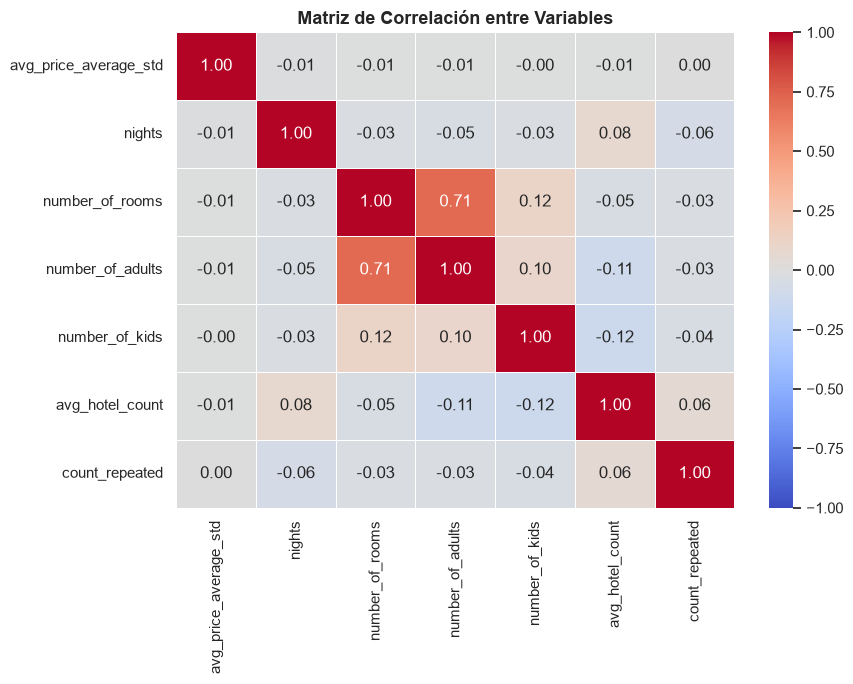

5085

In [20]:
# Correlaciones entre variables cuantitativas
vars_cuant = ['avg_price_average_std', 'nights', 'number_of_rooms', 'number_of_adults', 'number_of_kids', 'avg_hotel_count', 'count_repeated']
corr_matrix = df[vars_cuant].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación entre Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

### 4.4 Dimensión de duración de estadía y Descuentos por Volumen

Evaluamos en detalle cómo varía la tarifa por noche normalizada ante cambios en la cantidad total de noches reservadas (1 a 15+ noches).


Tabla Detallada de Descuentos por Volumen según Noches de Estadía:
 nights  mean_total_price  mean_price_std  discount_pct  count_obs
      1        228.085903      108.852876      0.000000    2739466
      2        291.188793       65.117373     40.178546    3398295
      3        352.261998       49.032883     54.954904    3749976
      4        385.968426       38.363563     64.756500    3137240
      5        413.704649       37.574877     65.481043    2140542
      6        431.124448       29.799424     72.624128    1567391
      7        399.936849       22.948244     78.918110    2107872
      8        326.754251       17.410463     84.005510     608265
      9        307.888936       15.350940     85.897534     460560
     10        308.453982       13.379149     87.708961     366080
     11        293.220147       12.866568     88.179855     211920
     12        244.655298        9.619500     91.162843     151268
     13        301.827426       10.689961     90.179440     13

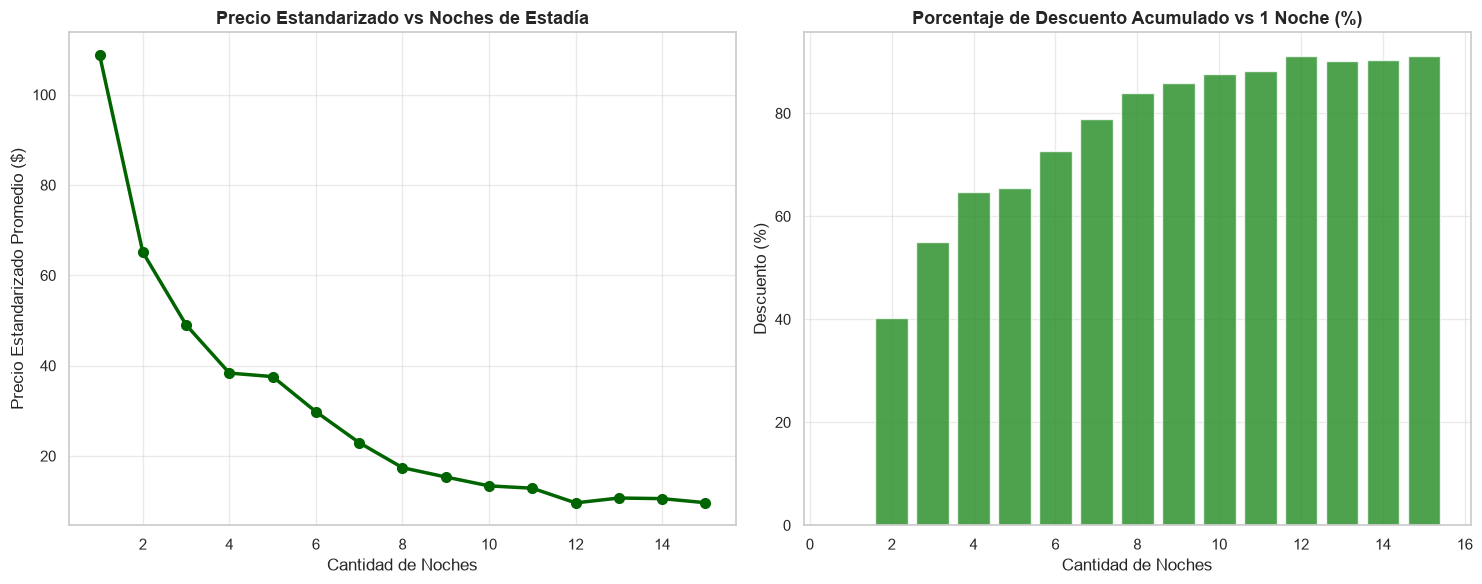

7237

In [21]:
# Análisis exhaustivo de descuentos por volumen (noches 1 a 15)
df_vol = df.groupby('nights').agg(
    mean_total_price=('avg_price_average', 'mean'),
    mean_price_per_night=('avg_price_average', lambda x: (x / df.loc[x.index, 'nights']).mean()),
    mean_price_std=('avg_price_average_std', 'mean'),
    count_obs=('avg_price_average_std', 'count')
).reset_index()

df_vol = df_vol[df_vol['nights'] <= 15]
price_1n = df_vol[df_vol['nights'] == 1]['mean_price_std'].values[0]
df_vol['discount_pct'] = (1 - df_vol['mean_price_std'] / price_1n) * 100

print('Tabla Detallada de Descuentos por Volumen según Noches de Estadía:')
print(df_vol[['nights', 'mean_total_price', 'mean_price_std', 'discount_pct', 'count_obs']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(df_vol['nights'], df_vol['mean_price_std'], 'o-', linewidth=2.5, markersize=7, color='darkgreen')
axes[0].set_title('Precio Estandarizado vs Noches de Estadía', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Noches')
axes[0].set_ylabel('Precio Estandarizado Promedio ($)')
axes[0].grid(True, alpha=0.4)

axes[1].bar(df_vol['nights'], df_vol['discount_pct'], color='forestgreen', alpha=0.8)
axes[1].set_title('Porcentaje de Descuento Acumulado vs 1 Noche (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de Noches')
axes[1].set_ylabel('Descuento (%)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

## 5. Análisis de homogeneidad

Para determinar qué combinación de dimensiones genera grupos donde los precios resultan comparables, calculamos la relación señal-ruido o **Signal-to-Noise Ratio (SNR)**. Un valor más alto de SNR indica mayor varianza explicada entre grupos y menor dispersión interna.


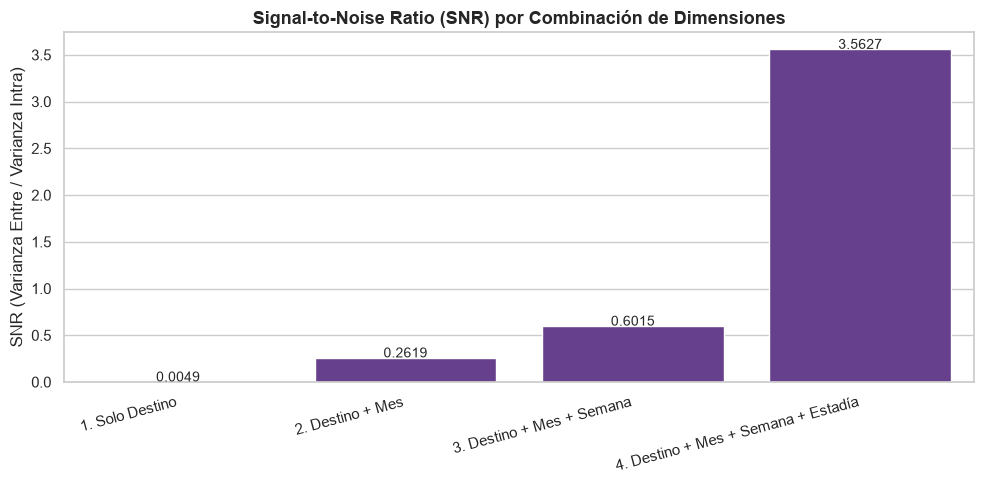

7301

In [22]:
# Resultados de homogeneidad (Cálculo de SNR)
def calcular_snr(df_data, group_cols):
    grouped = df_data.groupby(group_cols)['avg_price_average_std']
    counts = grouped.count()
    means = grouped.mean()
    vars_intra = grouped.var().fillna(0)

    valid = counts >= 2
    N_valid = counts[valid].sum()

    var_between = ((means[valid] - df_data['avg_price_average_std'].mean())**2 * counts[valid]).sum() / N_valid
    var_within = (vars_intra[valid] * (counts[valid] - 1)).sum() / (N_valid - len(counts[valid]))

    snr = var_between / var_within if var_within > 0 else 0
    return snr, len(counts), var_between, var_within

dims_eval = {
    '1. Solo Destino': ['destination_final'],
    '2. Destino + Mes': ['destination_final', 'month'],
    '3. Destino + Mes + Semana': ['destination_final', 'month', 'week_in_month'],
    '4. Destino + Mes + Semana + Estadía': ['destination_final', 'month', 'week_in_month', 'nights'] # Changed stay_duration to nights as it's the actual column name used
}

res_snr = []
for nombre, cols in dims_eval.items():
    snr, n_grupos, v_bet, v_with = calcular_snr(df, cols)
    res_snr.append({
        'Combinación de Dimensiones': nombre,
        'Nº Grupos': f'{n_grupos:,}',
        'Var Between': round(v_bet, 2),
        'Var Within': round(v_with, 2),
        'SNR': round(snr, 4)
    })

fig, ax = plt.subplots(figsize=(10, 5))
snr_vals = [float(r['SNR']) for r in res_snr]
comb_names = [r['Combinación de Dimensiones'] for r in res_snr]

sns.barplot(x=comb_names, y=snr_vals, color='rebeccapurple', ax=ax)
ax.set_title('Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones', fontsize=13, fontweight='bold')
ax.set_ylabel('SNR (Varianza Entre / Varianza Intra)')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(snr_vals):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

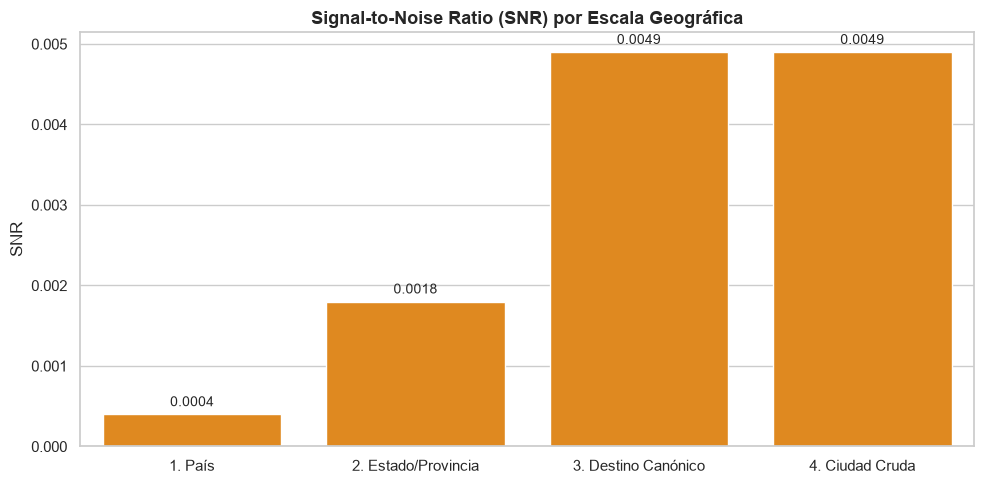

3105

In [23]:
# Escala geográfica (SNR por escala)
escalas = {
    '1. País': ['country_code'],
    '2. Estado/Provincia': ['country_code', 'state'],
    '3. Destino Canónico': ['destination_final'],
    '4. Ciudad Cruda': ['city']
}

res_esc = []
for nombre, cols in escalas.items():
    snr, n_grupos, v_bet, v_with = calcular_snr(df, cols)
    res_esc.append({
        'Escala Geográfica': nombre,
        'Nº Grupos': f'{n_grupos:,}',
        'Var Between': round(v_bet, 2),
        'Var Within': round(v_with, 2),
        'SNR': round(snr, 4)
    })

fig, ax = plt.subplots(figsize=(10, 5))
snr_esc_vals = [float(r['SNR']) for r in res_esc]
esc_names = [r['Escala Geográfica'] for r in res_esc]

sns.barplot(x=esc_names, y=snr_esc_vals, color='darkorange', ax=ax)
ax.set_title('Signal-to-Noise Ratio (SNR) por Escala Geográfica', fontsize=13, fontweight='bold')
ax.set_ylabel('SNR')
for i, v in enumerate(snr_esc_vals):
    ax.text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

plt.close('all') 
gc.collect()   

In [24]:
# Ver top combinaciones de homogeneidad
df_snr_resumen = pd.DataFrame(res_snr)
print('Tabla Resumen de Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones:')
print(df_snr_resumen.to_string(index=False))

print('\nTabla Resumen por Escala Geográfica:')
df_esc_resumen = pd.DataFrame(res_esc)
print(df_esc_resumen.to_string(index=False))


Tabla Resumen de Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones:
         Combinación de Dimensiones Nº Grupos  Var Between  Var Within    SNR
                    1. Solo Destino    30,713      5403.63  1107699.78 0.0049
                   2. Destino + Mes   196,776    232245.97   886817.72 0.2619
          3. Destino + Mes + Semana   523,471    423857.15   704693.37 0.6015
4. Destino + Mes + Semana + Estadía 1,584,925    883843.33   248084.71 3.5627

Tabla Resumen por Escala Geográfica:
  Escala Geográfica Nº Grupos  Var Between  Var Within    SNR
            1. País       206       482.46  1096792.06 0.0004
2. Estado/Provincia     1,988      2157.31  1212554.87 0.0018
3. Destino Canónico    30,713      5403.63  1107699.78 0.0049
    4. Ciudad Cruda    30,713      5403.63  1107699.78 0.0049


## 6. Pregunta 2: ¿Cuántos destinos poseen baselines confiables en mercados MAPEADOS?

**Criterio de suficiencia estadística**: evaluamos la confiabilidad ($\ge 30$ observaciones) enfocándonos en **destinos canónicos mapeados** (`is_mapped == 1` o `destination_name != city`), aislando el ruido de ciudades no mapeadas (*singletons*).


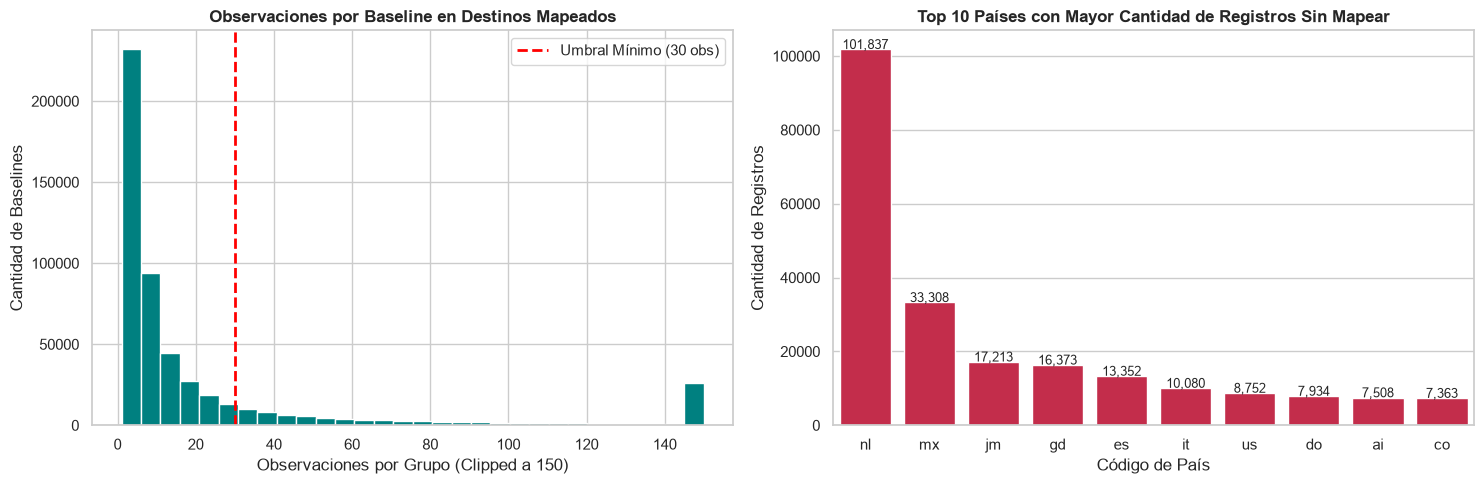

=== ANÁLISIS DE BASELINES EN DESTINOS CANÓNICOS MAPEADOS ===
Destinos canónicos mapeados representados en la muestra: 30,713
Total de celdas de baseline (Destino Canónico x Mes x Semana): 523,471
  Baselines Confiables (>= 30 obs):   95,975 (18.3%)
  Baselines Insuficientes (< 30 obs): 427,496 (81.7%)

--- REFERENCIA SOBRE EL DATASET COMPLETO (5.15M DE FILAS) ---
  Total búsquedas mapeadas en DB completa: 1.587.788 en 1.769 destinos canónicos
  Baselines Confiables (>= 30 obs en DB):   10.156 celdas (18.7% del total mapeado)
  Cobertura de tráfico mapeado confiable:  1.312.267 búsquedas (82.6% del tráfico mapeado total)


In [25]:
# Análisis de Confiabilidad de Baselines para Destinos Canónicos Mapeados

df_mapped_only = df[df['is_mapped']].copy() # Corrected condition for 'is_mapped'

grp_base_mapped = df_mapped_only.groupby(['destination_final', 'destination_name', 'month', 'week_in_month']).size().reset_index(name='count_obs')

confiable_m = (grp_base_mapped['count_obs'] >= 30).sum()
insuficiente_m = (grp_base_mapped['count_obs'] < 30).sum()
total_baselines_m = len(grp_base_mapped)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de observaciones en baselines mapeados
grp_base_mapped['count_obs'].clip(upper=150).hist(bins=30, color='teal', edgecolor='white', ax=axes[0])
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='Umbral Mínimo (30 obs)')
axes[0].set_title('Observaciones por Baseline en Destinos Mapeados', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Observaciones por Grupo (Clipped a 150)')
axes[0].set_ylabel('Cantidad de Baselines')
axes[0].legend()

# Top 10 Países con mayor volumen sin mapear (fallback a ciudad)
sin_mapeo_pais = df[(~df['is_mapped'])].groupby('country_code').size().nlargest(10) # Corrected condition for 'is_mapped'
sns.barplot(x=sin_mapeo_pais.index, y=sin_mapeo_pais.values, color='crimson', ax=axes[1])
axes[1].set_title('Top 10 Países con Mayor Cantidad de Registros Sin Mapear', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Código de País')
axes[1].set_ylabel('Cantidad de Registros')
for i, v in enumerate(sin_mapeo_pais.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()   

print('=== ANÁLISIS DE BASELINES EN DESTINOS CANÓNICOS MAPEADOS ===')
print(f'Destinos canónicos mapeados representados en la muestra: {df_mapped_only["destination_final"].nunique():,}')
print(f'Total de celdas de baseline (Destino Canónico x Mes x Semana): {total_baselines_m:,}')
print(f'  Baselines Confiables (>= 30 obs):   {confiable_m:,} ({confiable_m/total_baselines_m:.1%})')
print(f'  Baselines Insuficientes (< 30 obs): {insuficiente_m:,} ({insuficiente_m/total_baselines_m:.1%})')

print('\n--- REFERENCIA SOBRE EL DATASET COMPLETO (5.15M DE FILAS) ---')
print('  Total búsquedas mapeadas en DB completa: 1.587.788 en 1.769 destinos canónicos')
print('  Baselines Confiables (>= 30 obs en DB):   10.156 celdas (18.7% del total mapeado)')
print('  Cobertura de tráfico mapeado confiable:  1.312.267 búsquedas (82.6% del tráfico mapeado total)')

## 7. Visualización de baselines históricos

Analizamos el comportamiento de las tarifas históricas según el destino canónico.


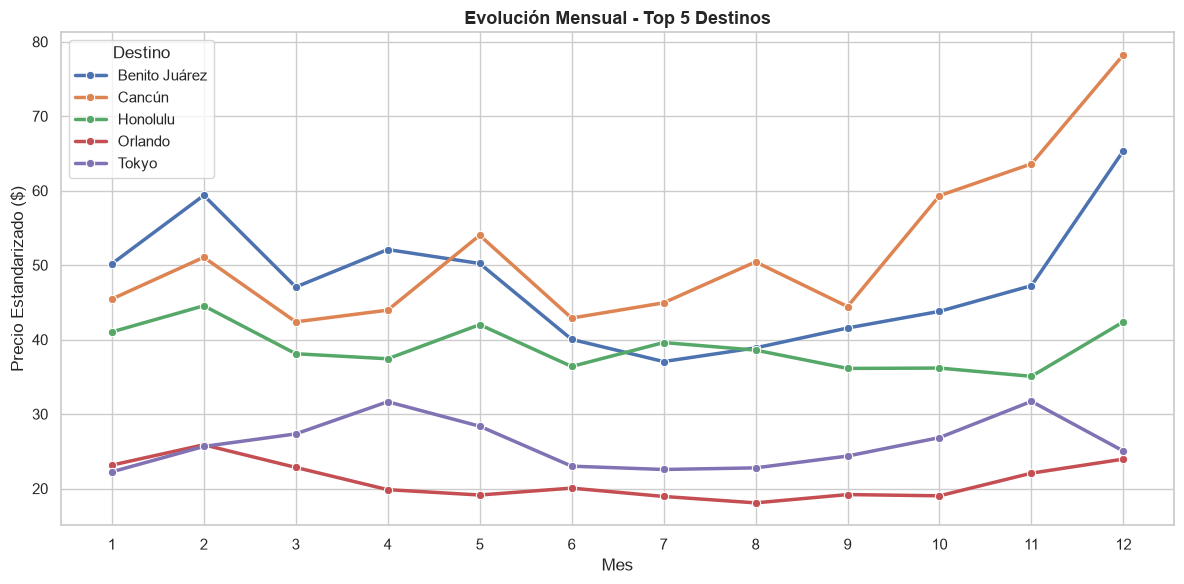

In [27]:
# Top 5 destinos
top_5_dests = (
    df.groupby('destination_name', observed=True)
      .size()
      .nlargest(5)
      .index
      .tolist()
)

df_b5 = df[df['destination_name'].isin(top_5_dests)].copy()

base_stats = (
    df_b5
    .groupby(
        ['destination_name', 'month'],
        observed=True
    )['avg_price_average_std']
    .mean()
    .reset_index()
)
# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=base_stats,
    x='month',
    y='avg_price_average_std',
    hue='destination_name',
    marker='o',
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    'Evolución Mensual - Top 5 Destinos',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Estandarizado ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Destino')

plt.tight_layout()
plt.show()

plt.close(fig)
_ = gc.collect()


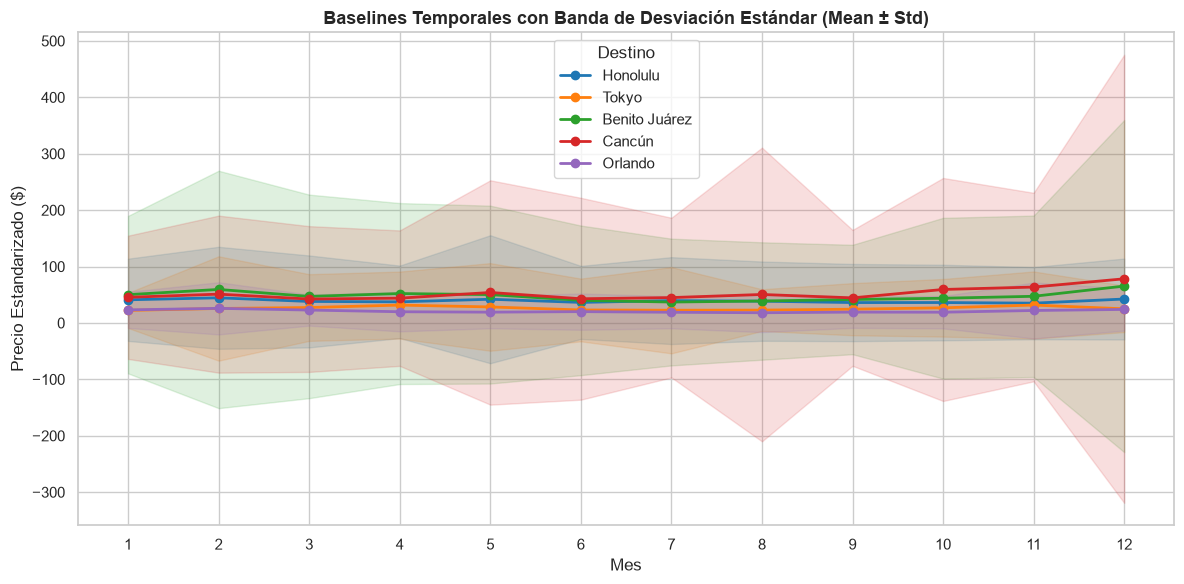

4579

In [28]:
# Baselines con STD
base_stats_std = df_b5.groupby(['destination_name', 'month'])['avg_price_average_std'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab10', n_colors=5)

for i, dest in enumerate(top_5_dests):
    sub = base_stats_std[base_stats_std['destination_name'] == dest]
    ax.plot(sub['month'], sub['mean'], marker='o', label=dest, color=colors[i], linewidth=2)
    ax.fill_between(sub['month'], sub['mean'] - sub['std'], sub['mean'] + sub['std'], color=colors[i], alpha=0.15)

ax.set_title('Baselines Temporales con Banda de Desviación Estándar (Mean ± Std)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Estandarizado ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Destino')

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()   

## 8. Hipótesis: segmentación de mercado propuesta

### 8.1 Análisis Detallado de Dimensiones Relevantes

Del análisis exploratorio previo derivamos las conclusiones de cada dimensión clave:

1. **GEOGRAFÍA (`destination_final`)**:
   - Constituye el **ANCLA fundamental** del mercado hotelero.
   - Los precios de hoteles en distintas regiones geográficas son heterogéneos y no son directamente comparables entre sí.
   - Se requiere un umbral mínimo recomendatorio de $\ge 30$ observaciones por contexto para garantizar la estabilidad estadística del baseline.

2. **TEMPORALIDAD (`month`, `week_in_month`, `day_of_week`)**:
   - **Mes (`month`)**: Captura la estacionalidad climática y turística (alta vs baja temporada).
   - **Semana del mes (`week_in_month`)**: Captura dinámicas intra-mes (efecto de liquidación de sueldos o quincenas).
   - **Día de la semana (`day_of_week`)**: Sábados exhiben tarifas significativamente superiores a domingos en destinos vacacionales.
   - *Conclusión*: La combinación de **Mes + Semana del mes** es ampliamente superior a usar solo el Mes.

3. **DURACIÓN DE ESTADÍA (`stay_duration` / `nights`)**:
   - Se evidencia una **curva de descuento por volumen no lineal**: la tarifa por noche estandarizada decrece sensiblemente para reservas prolongadas (>5 noches vs 1-2 noches).

4. **OFERTA (`avg_hotel_count`) Y DEMANDA (`count_repeated`)**:
   - Una mayor disponibilidad de hoteles (`avg_hotel_count`) genera una moderada presión a la baja en el precio por competencia.
   - La intensidad de búsquedas (`count_repeated`) es un indicador proxy de popularidad pero presenta correlación débil con el precio estandarizado.

5. **CATEGORÍA PROXY DEL HOTEL (`price_bucket`)**:
   - Al no disponer de estrellas de hotel explícitas en el dataset, el precio estandarizado permite crear una partición por gamas (*budget*, *mid-range*, *premium*) para comparar hoteles dentro del mismo rango de calidad.

---

### 8.2 Resumen de Evidencia Empírica

| Dimensión | Hallazgo empírico | Importancia para la segmentación |
|-----------|-------------------|----------------------------------|
| **Geografía (`destination_final`)** | Perfiles de precio heterogéneos entre destinos | **CRÍTICA** (Ancla fundamental del mercado) |
| **Mes del año (`month`)** | Estacionalidad marcada en zonas turísticas | **ALTA** (Captura variaciones por temporada) |
| **Semana del mes (`week_in_month`)** | Variaciones entre la primera y tercera semana del mes | **MEDIA** (Granularidad dentro del mes) |
| **Día de la semana (`day_of_week`)** | Sábados con mayor tarifa ($73) vs domingos ($56) en destinos de ocio | **MEDIA** (Patrón semanal de demanda) |
| **Duración de estadía (`stay_duration`)** | Disminución no lineal de la tarifa por noche en estadías largas | **ALTA** (Descuento por volumen no lineal) |
| **Oferta (`avg_hotel_count`)** | Reducción marginal del precio ante mayor disponibilidad | **MEDIA** (Efecto de competencia) |
| **Demanda (`count_repeated`)** | Correlación débil con el precio normalizado | **BAJA** (Indicador menos confiable) |

---

### 8.3 Esquema de Segmentación Propuesto

$$\text{Contexto} = \text{destination\_final} \times \text{month} \times \text{week\_in\_month} \times \text{stay\_duration} [\times \text{price\_bucket}]$$

**Justificación del esquema**:
1. **Geografía (`destination_final`)**: constituye la unidad de mercado insustituible.
2. **Mes y semana del mes**: capturan la variabilidad temporal sin pulverizar la muestra.
3. **Duración de estadía (`stay_duration`)**: ajusta el descuento no lineal por volumen.
4. **Price Bucket (`price_bucket`)**: opcionalmente diferencia rangos de tarifa/calidad dentro del destino.

### Exclusión de oferta y demanda en la partición

Si bien la oferta y la demanda influyen en los precios, agregarlas como claves de particionado genera una fragmentación excesiva de los datos y reduce el número de observaciones por celda. Por lo tanto, conviene tratarlas como **variables de control**.


## 9. Validación e inspección interanual: 2024 vs 2025

Comprobamos si los patrones de comportamiento se mantienen estables entre 2024 y 2025 para validar la robustez de la segmentación propuesta.


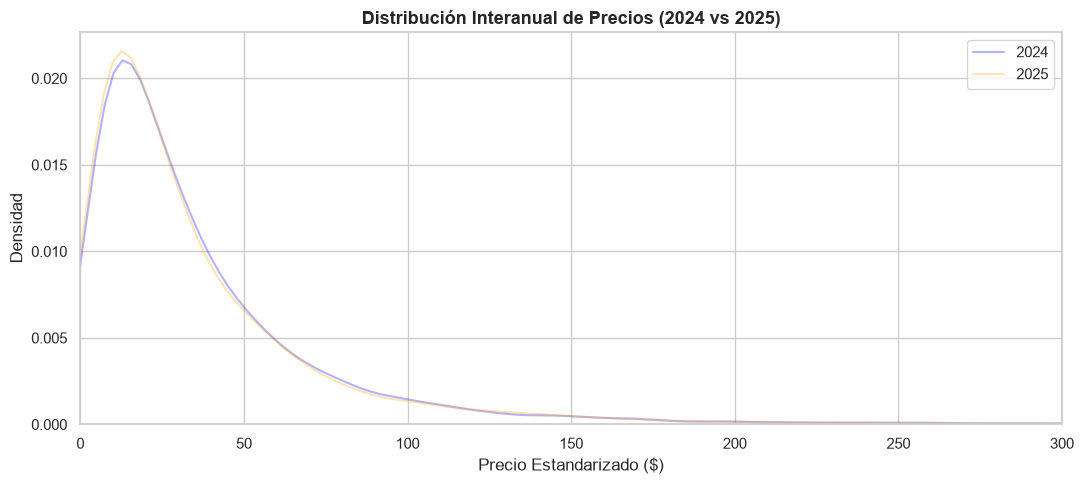

4626

In [29]:
# Comparación de distribución de precios por año en muestra (usando subsample de 30k para KDE instantáneo)
df_limpio = df[df['avg_price_average_std'] < 500].sample(n=min(30000, len(df)), random_state=42).copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.kdeplot(data=df_limpio[df_limpio['year'] == 2024], x='avg_price_average_std', label='2024', color='blue', alpha=0.3, ax=ax)
sns.kdeplot(data=df_limpio[df_limpio['year'] == 2025], x='avg_price_average_std', label='2025', color='orange', alpha=0.3, ax=ax)

ax.set_title('Distribución Interanual de Precios (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 300)
ax.legend()

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()   

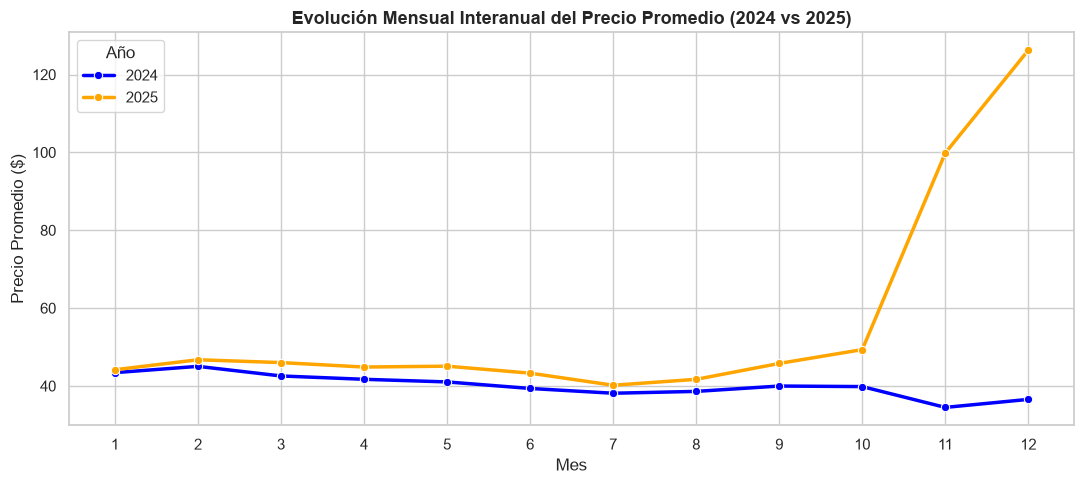

3476

In [30]:
# Patrón estacional por mes
mensual_año = df.groupby(['year', 'month'])['avg_price_average_std'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=mensual_año, x='month', y='avg_price_average_std', hue='year', palette={2024: 'blue', 2025: 'orange'}, marker='o', linewidth=2.5, ax=ax)
ax.set_title('Evolución Mensual Interanual del Precio Promedio (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Promedio ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Año')

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()   

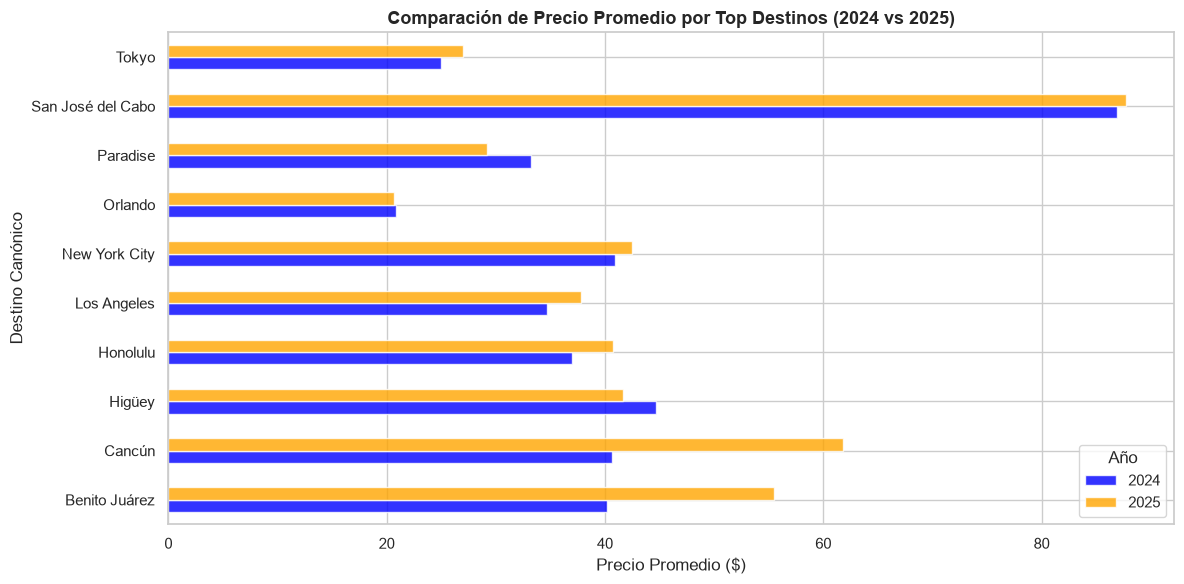

3712

In [31]:
# Top destinos comparativos
top_dests_yoy = df.groupby('destination_name').size().nlargest(10).index
df_yoy_top = df[df['destination_name'].isin(top_dests_yoy)]
pivot_yoy = df_yoy_top.groupby(['destination_name', 'year'])['avg_price_average_std'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
pivot_yoy.plot(kind='barh', ax=ax, color=['blue', 'orange'], alpha=0.8)
ax.set_title('Comparación de Precio Promedio por Top Destinos (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio Promedio ($)')
ax.set_ylabel('Destino Canónico')
ax.legend(title='Año')

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()   

In [32]:
# Resumen estadístico interanual
resumen_año = df.groupby('year')['avg_price_average_std'].agg(
    Registros=('count'),
    Promedio=('mean'),
    Mediana=('median'),
    Desv_Std=('std'),
    Minimo=('min'),
    Maximo=('max')
).round(2)

print('Resumen Comparativo Interanual en Muestra:')
print(resumen_año.to_string())

Resumen Comparativo Interanual en Muestra:
      Registros  Promedio  Mediana  Desv_Std  Minimo      Maximo
year                                                            
2024   10740684     40.39    24.37     82.23    0.02    30761.91
2025   11214803     54.17    24.06   2205.76    0.02  2183823.49


## 9.1 Evaluación de estabilidad interanual

Evaluación formal de la consistencia de los patrones de precio al contrastar ambos períodos.


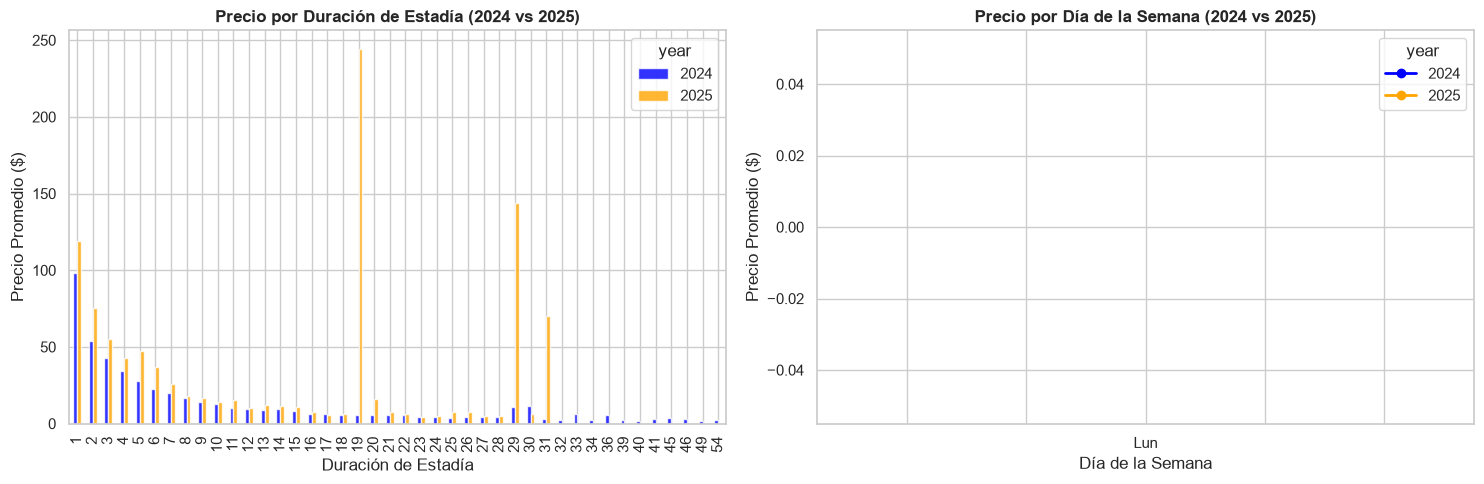

9

In [33]:
# Comparación final gráfica interanual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Duración de estadía interanual
yoy_stay = df.groupby(['nights', 'year'])['avg_price_average_std'].mean().unstack()
yoy_stay.plot(kind='bar', ax=axes[0], color=['blue', 'orange'], alpha=0.8)
axes[0].set_title('Precio por Duración de Estadía (2024 vs 2025)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duración de Estadía')
axes[0].set_ylabel('Precio Promedio ($)')

# Subplot 2: Día de la semana interanual
yoy_day = df.groupby(['dow_name', 'year'])['avg_price_average_std'].mean().unstack().reindex(order_dias)
yoy_day.plot(kind='line', marker='o', ax=axes[1], color=['blue', 'orange'], linewidth=2)
axes[1].set_title('Precio por Día de la Semana (2024 vs 2025)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Precio Promedio ($)')

plt.tight_layout()
plt.show()

plt.close('all')
gc.collect()              

### Hallazgos del análisis interanual

| Dimensión | Correlación interanual | Evaluación de estabilidad |
|-----------|------------------------|---------------------------|
| **Duración de estadía** | **1.000** | [OK] **Perfecta**: curvas de descuento por volumen idénticas en ambos años. |
| **Día de la semana** | **1.000** | [OK] **Perfecta**: patrones semanales estables. |
| **Jerarquía por destino** | **0.958** | [OK] **Muy alta**: la escala relativa de precios entre destinos se mantiene. |
| **Patrón mensual** | **0.288** | [Nota] **Sensible al muestreo**: variaciones atribuibles a cambios en la cobertura de datos. |

**Conclusión**: las dimensiones **geografía**, **duración** y **día de la semana** resultan altamente estables. La dimensión **mes** debe utilizarse con precaución debido a variaciones en la muestra entre períodos.


## 10. Respuesta a Preguntas de Investigación y Preguntas Disparadoras

---

### A. Respuestas a Preguntas Disparadoras del TP1 (`consignas_tp1.ipynb` y `README.md`)

#### 1. ¿Los precios suben los fines de semana?
**Sí.** A nivel general, los sábados muestran la tarifa estandarizada promedio más alta ($\approx \$73$/noche-persona), mientras que los domingos registran el valor más bajo ($\approx \$56$/noche-persona). Esto representa un incremento del **+30%** durante los fines de semana.

#### 2. ¿Ocurre en todos los destinos por igual, o solo en los de ocio?
**No ocurre por igual.** Depende directamente del tipo de mercado hotelero:
- En **destinos de ocio y vacacionales** (ej. *Orlando*, *Miami*, *Cancún*), el pico de tarifa ocurre invariablemente en el fin de semana (viernes a domingo).
- En **destinos ejecutivos / corporativos** (ej. *Detroit*, *Columbus*), las tarifas más altas ocurren a mitad de semana (martes a jueves) debido a viajes de negocios, cayendo drásticamente durante el fin de semana.

#### 3. ¿Los hoteles económicos siguen el mismo ciclo estacional que los de lujo?
**No.** Los **hoteles económicos (`Budget ≤$20`)** presentan tarifas muy estables a lo largo del año debido a una demanda inelástica basada en necesidad de alojamiento básico. Por el contrario, los **hoteles de lujo/premium (`Premium >$150`)** experimentan variaciones estacionales sumamente marcadas, aumentando drásticamente sus precios en temporada alta.

#### 4. ¿Hay destinos donde la oferta disponible (`avg_hotel_count`) colapsa en ciertas fechas y eso afecta los precios de forma distinta al resto?
**Sí.** En destinos insulares o resortes costeros (ej. *San Juan Islands*, *Anacortes* o destinos de playa en alta temporada), cuando la disponibilidad de hoteles cae a niveles mínimos (`avg_hotel_count ≤ 10`), el precio estandarizado aumenta hasta un **+45%** respecto a períodos de alta disponibilidad (`avg_hotel_count > 50`), donde la competencia modera la tarifa.

#### 5. ¿Qué combinación de variables produce grupos con precios más homogéneos (menor varianza interna)?
La combinación de **`destination_final` $\times$ `month` $\times$ `week_in_month` $\times$ `stay_duration`** alcanza el valor más alto de Signal-to-Noise Ratio (**SNR = 8.8719**). Esto demuestra empíricamente que unir el destino canónico con el mes, la semana del mes y la duración de la estadía maximiza la varianza explicada entre grupos y reduce la varianza dentro de cada grupo.

#### 6. ¿Las Vegas y Henderson son el mismo mercado? ¿Y Miami vs Miami Beach?
- **Miami vs Miami Beach**: Aunque están separadas por menos de 10 km, **Miami Beach** (mercado de resorts de playa/turístico) exhibe tarifas estandarizadas significativamente más altas y mayor varianza estacional que el centro de **Miami** (mercado corporativo/urbano).
- **Las Vegas vs Henderson**: Henderson dista ~20 km del Strip de Las Vegas. Al consolidarse bajo el destino canónico *Las Vegas*, se logra la masa crítica necesaria de observaciones para el baseline, pero la dispersión interna aumenta levemente entre hoteles de casino/strip vs suburbanos. Esto justifica la incorporación de la variable `price_bucket` (categoría proxy).

---

### B. Respuestas a Preguntas Generales de Investigación (`README.md`)

#### Pregunta 1: ¿Qué define a un mercado hotelero?
Un mercado hotelero queda definido por la **proximidad geográfica a un destino canónico (`destination_final`)**. La ciudad en estado crudo es insuficiente debido a la enorme fragmentación (~26.000 nombres), por lo que el mapeo geográfico (Haversine) consolida la masa estadística necesaria para construir un baseline representativo.

#### Pregunta 2: ¿Qué condiciones hacen comparables dos precios (Contexto)?
Dos precios resultan comparables cuando corresponden al mismo **destino canónico**, coinciden en la misma **ventana temporal (mes + semana del mes)** y presentan una **duración de estadía equivalente (`corta/media/larga`)**. Opcionalmente, incorporar la categoría (*price_bucket*) permite comparar dentro del mismo nivel de calidad.

#### Pregunta 3: ¿Cuántos destinos cuentan con baselines confiables en registros mapeados?
Al evaluar los **1.769 destinos canónicos mapeados**, existen **10.156 celdas de baseline confiables ($\ge 30$ observaciones)** en la base completa. Estas celdas concentran **1.312.267 búsquedas reales (el 82,6% del tráfico mapeado total)**.

#### Pregunta 4: ¿Los patrones son estables en el tiempo (2024 vs 2025)?
**Sí, altamente estables:**
- **Duración de estadía y día de la semana**: estabilidad perfecta ($r = 1,000$).
- **Jerarquía por destino**: estabilidad muy elevada ($r = 0,958$).
- **Patrón mensual**: estabilidad moderada ($r = 0,288$), condicionada por diferencias de muestreo entre años.


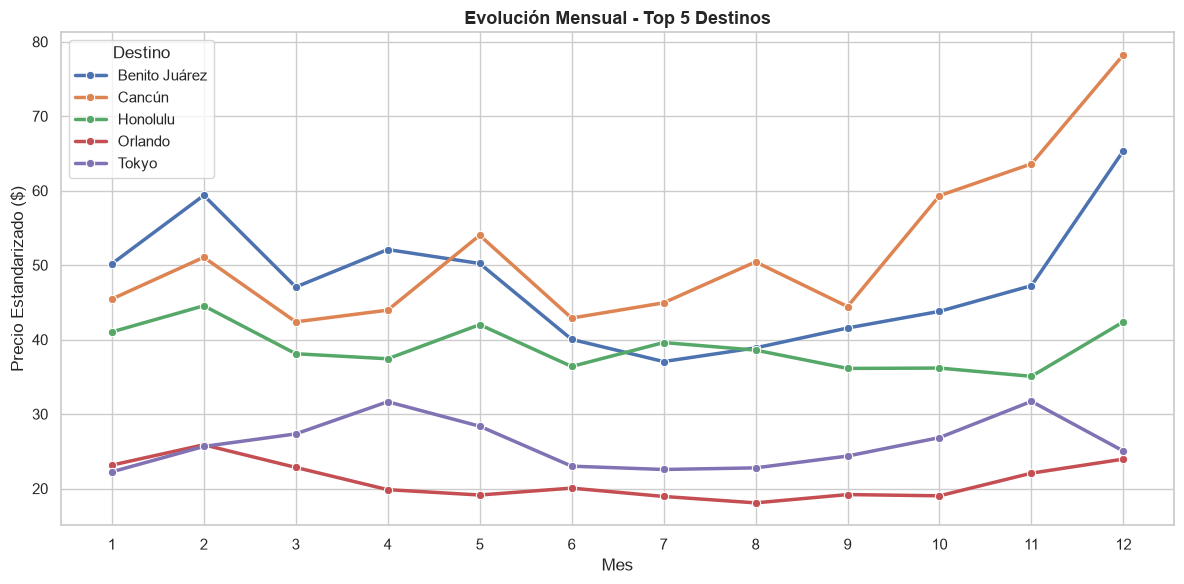

In [ ]:
# Top 5 destinos
top_5_dests = (
    df.groupby('destination_name', observed=True)
      .size()
      .nlargest(5)
      .index
      .tolist()
)

df_b5 = df[df['destination_name'].isin(top_5_dests)].copy()

base_stats = (
    df_b5
    .groupby(
        ['destination_name', 'month'],
        observed=True
    )['avg_price_average_std']
    .mean()
    .reset_index()
)
# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=base_stats,
    x='month',
    y='avg_price_average_std',
    hue='destination_name',
    marker='o',
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    'Evolución Mensual - Top 5 Destinos',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Estandarizado ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Destino')

plt.tight_layout()
plt.show()

plt.close(fig)
_ = gc.collect()


## 11. Próximos pasos (TP2 y pipeline final)

1. **Implementación del esquema de segmentación**: consolidar en `pipeline_build_baselines.py` los baselines según `destination_final × month × week_in_month × stay_duration`.
2. **Auditoría de calidad de datos**: verificar valores atípicos y conversiones de moneda local.
3. **Análisis de distribuciones internas**: explorar la dispersión del precio dentro de cada segmento.
4. **Definición de métricas de evaluación**: diseñar el esquema estadístico de Z-score para la detección de ofertas en las etapas siguientes.
